#**KNOWLEDGE GRAPH EXPLOITATION**

This is the notebook associated with the assignment **Knowledge Graph Exploitation**. In LearnSQL you can find the assignment statament, so please carefully read it while following the scripts, answering all the questions and compleating the tasks. Remember to change the **Runtime** settings to include GPU access.

Before starting, we will install and import the required libraries:

In [1]:
!pip install torch torchvision torchaudio
!pip install torch-geometric
!pip install pykeen


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## **Creating the Knowledge Graph**

In [3]:
import numpy as np
from pykeen.triples import TriplesFactory
from torch_geometric.datasets import Planetoid


dataset = Planetoid(root='data/PubMed', name='PubMed')
data = dataset[0]

edge_index = data.edge_index

# Convert to numpy
heads = edge_index[0].cpu().numpy()
tails = edge_index[1].cpu().numpy()

# Create string triples
triples = np.array([
    [f"paper_{h}", "cites", f"paper_{t}"]
    for h, t in zip(heads, tails)
])

tf = TriplesFactory.from_labeled_triples(triples)

training, testing, validation = tf.split([0.8, 0.1, 0.1],random_state=2026)

c:\Users\berta\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Processing...
c:\Users\berta\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch_geometric\io\planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.load(f, encoding='latin1')
c:\Users\berta\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch_geometric\io\planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.load(f, encoding='latin1')
c:\Users\berta\AppData\Local\Python\

# A.1 The Most Basic Model

TransE is the simplest translational KGE model. It learns an embedding vector for each entity and each relation such that, for every true triple (h, r, t), the equation $h + r \approx t$ holds in the embedding space. In this case, the PubMed citation graph contains 19717 papers and a single relation type ("cites"), so the model learns 19717 entity vectors and one relation vector.

The model is trained using PyKEEN's pipeline with the following configuration: embedding dimension of 64, 100 epochs, Adam optimizer with learning rate 0.001, margin ranking loss with margin 1.0, and uniform negative sampling with 1 negative sample per positive triple.

Once trained, a paper is chosen (paper_0) and its citations are read directly from the graph. The embeddings of the cited papers are averaged to obtain a representative "citation target" vector. Then, using TransE's equation in reverse, the ideal head embedding is computed as $x = avg(t_i) - r$. This vector represents the embedding of a hypothetical paper that would cite works similar to those cited by paper_0. Since this exact vector does not correspond to any real paper, the closest real paper in the embedding space is retrieved using Euclidean distance, excluding paper_0 itself. Finally, the relevant embeddings are projected to 2D using PCA for visualization.

In [15]:
# Training TransE

from pykeen.pipeline import pipeline

result = pipeline(
    training=training,
    testing=testing,
    validation=validation,
    model='TransE',
    model_kwargs=dict(embedding_dim=64),
    epochs=100,
    optimizer='Adam',
    optimizer_kwargs=dict(lr=0.001),
    loss='MarginRankingLoss',
    loss_kwargs=dict(margin=1.0),
    negative_sampler='basic',
    negative_sampler_kwargs=dict(num_negs_per_pos=1),
    random_seed=42,
)

# Extract embeddings
model = result.model
entity_embs = model.entity_representations[0](indices=None).detach().cpu().numpy()
relation_embs = model.relation_representations[0](indices=None).detach().cpu().numpy()
r = relation_embs[0]

# Pick a paper and find its citations
paper_id = 'paper_0'
paper_idx = tf.entity_to_id[paper_id]
cited_papers = triples[triples[:, 0] == paper_id][:, 2]
print(f"{paper_id} cites: {cited_papers}")

# Use 5 cited papers for cleaner visualization
cited_papers_subset = cited_papers[:5]
cited_indices_subset = [tf.entity_to_id[p] for p in cited_papers_subset]

# Average the cited papers' embeddings
avg_tail = entity_embs[cited_indices_subset].mean(axis=0)

# Compute x = avg - r
x = avg_tail - r

# Find closest real paper, excluding paper_0
from scipy.spatial.distance import cdist
distances = cdist(x.reshape(1, -1), entity_embs, metric='euclidean')[0]
distances[paper_idx] = float('inf')
closest_idx = distances.argmin()
closest_emb = entity_embs[closest_idx]

id_to_entity = {v: k for k, v in tf.entity_to_id.items()}
print(f"Closest paper: {id_to_entity[closest_idx]}")
print(f"Distance: {distances[closest_idx]:.4f}")

INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
c:\Users\berta\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Training epochs on cpu: 100%|██████████| 100/100 [02:12<00:00,  1.32s/epoch, loss=0.00422, prev_loss=0.00474]
Evaluating on cpu:   0%|          | 0.00/8.87k [00:00<?, ?triple/s]WARNING:torch_max_mem.api:Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
Evaluating on cpu: 100%|██████████| 8.87k/8.87k [00:34<00:00, 258triple/s]
INFO:pykeen.evaluation.evaluator:Evaluation took 34.71s seconds


paper_0 cites: ['paper_1378' 'paper_1544' 'paper_6092' 'paper_7636' 'paper_14442']
Closest paper: paper_14442
Distance: 0.6896


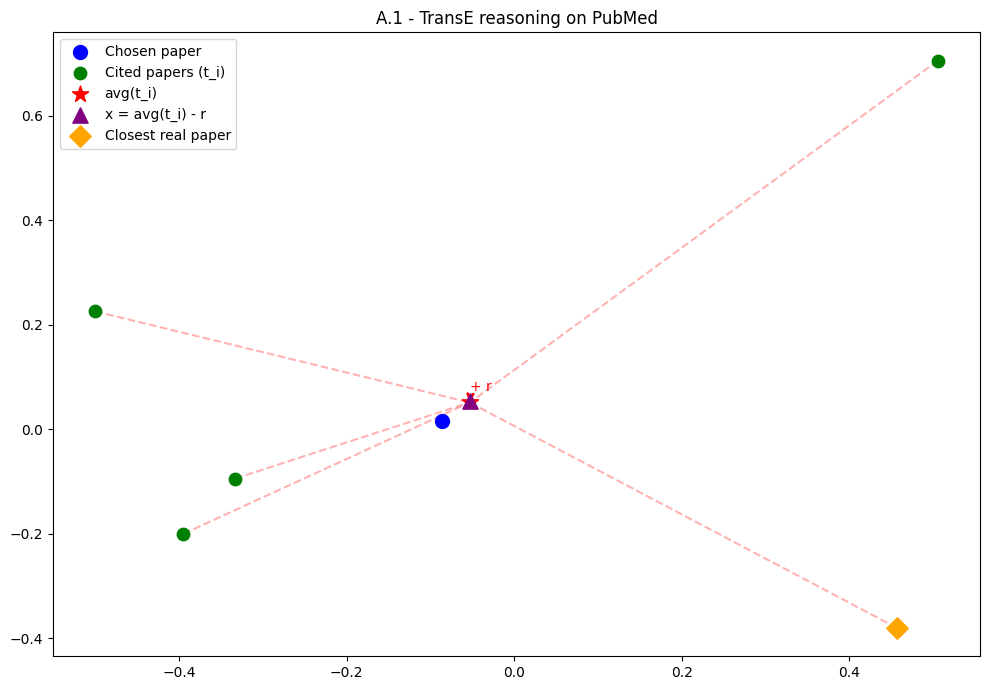

In [16]:
# 2D Sketch
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

all_vecs = np.vstack([
    entity_embs[paper_idx],
    entity_embs[cited_indices_subset],
    avg_tail,
    x,
    closest_emb,
])

pca = PCA(n_components=2)
vecs_2d = pca.fit_transform(all_vecs)
n = len(cited_papers_subset)

plt.figure(figsize=(10, 7))

# Original paper
plt.scatter(*vecs_2d[0], c='blue', s=100, zorder=5)
plt.scatter([], [], c='blue', s=100, label='Chosen paper')

# Cited papers
for i in range(1, 1 + n):
    plt.scatter(*vecs_2d[i], c='green', s=80, zorder=5)
plt.scatter([], [], c='green', s=80, label='Cited papers (t_i)')

# Average of cited
avg_2d = vecs_2d[1 + n]
plt.scatter(*avg_2d, c='red', s=150, marker='*', zorder=5)
for i in range(1, 1 + n):
    plt.plot([vecs_2d[i][0], avg_2d[0]], [vecs_2d[i][1], avg_2d[1]], 'r--', alpha=0.3)
plt.scatter([], [], c='red', s=150, marker='*', label='avg(t_i)')

# x = avg - r
x_2d = vecs_2d[1 + n + 1]
plt.scatter(*x_2d, c='purple', s=120, marker='^', zorder=5)
plt.annotate('', xy=avg_2d, xytext=x_2d,
             arrowprops=dict(arrowstyle='->', color='red', lw=2))
plt.annotate('+ r', ((x_2d[0]+avg_2d[0])/2, (x_2d[1]+avg_2d[1])/2 + 0.02),
             fontsize=10, color='red')
plt.scatter([], [], c='purple', s=120, marker='^', label='x = avg(t_i) - r')

# Closest real paper
closest_2d = vecs_2d[-1]
plt.scatter(*closest_2d, c='orange', s=120, marker='D', zorder=5)
plt.scatter([], [], c='orange', s=120, marker='D', label='Closest real paper')

plt.title('A.1 - TransE reasoning on PubMed')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [17]:
print(f"Chosen paper: {paper_id}")
print(f"Papers it cites (subset): {list(cited_papers_subset)}")
print(f"Closest paper found: {id_to_entity[closest_idx]}")
print(f"Distance to x: {distances[closest_idx]:.4f}")

Chosen paper: paper_0
Papers it cites (subset): [np.str_('paper_1378'), np.str_('paper_1544'), np.str_('paper_6092'), np.str_('paper_7636'), np.str_('paper_14442')]
Closest paper found: paper_14442
Distance to x: 0.6896


The retrieved paper is the paper_14442, which according to the TransE embedding space is the paper most likely to cite similar works as paper_0. The 2D projection shows that the average of the cited papers' embeddings and the computed $x = avg - r$ are very close to each other, indicating that the learned relation vector r has a small magnitude. This is expected in a Knowledge Graph with a single relation type, since TransE does not need a large displacement to distinguish different relations. Note that PCA plot is used for visualization since the embeddings live in a 64-dimension space.

## **A.2 Improving TransE**

In [ ]:
# Find the requested paper here

## **A.3 Training KGEs**

In [ ]:
# Train the different KGE models

## **A.4 Negative Sampling**

In [ ]:
# Obtain the corruption probabilities here

## **Loading the full PubMed Dataset**

In [ ]:
from torch_geometric.datasets import Planetoid

dataset = Planetoid(root='data/PubMed', name='PubMed')
data = dataset[0]

print(data)
print("Number of node features:", dataset.num_node_features)
print("Number of classes:", dataset.num_classes)

data = data.to('cuda' if torch.cuda.is_available() else 'cpu')

## **B.1: Let's Forget About the Graph**

In [ ]:
import numpy as np

X = data.x.cpu().numpy()
y = data.y.cpu().numpy()

train_mask = data.train_mask.cpu().numpy()
test_mask = data.test_mask.cpu().numpy()

X_train = X[train_mask]
y_train = y[train_mask]

X_test = X[test_mask]
y_test = y[test_mask]

With the dataset above, train three or four simple classifiers (e.g., SVM, LR, RF, KNN...) and report the accuracy score over the test set for them.

*Note: use **sklearn** for simplicity.*

## **B.2: Exploiting the Graph Structure**

Now, we are going to create a GNN with graph layers and a final linear layer. Refer to the Lab Statement for more details of how to implement the architecture. You should report your designed architecutre(s) and the accuracy results.

In [ ]:
import torch
import torch.nn.functional as F
from torch import nn
# Remember to import the GNN modules you want to use


class GNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels): #You can change it at will (e.g., two different hidden channel sizes)
        super().__init__()

        # Your code here

    def forward(self, x, edge_index, return_embeddings=False):
        # Your code here

        return x


In [ ]:
# You are provided with a simple training and testing loop. Feel free to create your own improved versions.

gnn_model = GNN(dataset.num_node_features, 256, dataset.num_classes).to(device) #Remember to change it if you change the input parameters in the GNN class
optimizer = torch.optim.Adam(gnn_model.parameters(), lr=0.01, weight_decay=5e-4)


def train_gnn(model):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def test_gnn(model):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    correct = pred[data.test_mask] == data.y[data.test_mask]
    acc = int(correct.sum()) / int(data.test_mask.sum())
    return acc

for epoch in range(500):
    loss = train_gnn(gnn_model)

gnn_acc = test_gnn(gnn_model)
print("Test Accuracy:", gnn_acc)

## **B.4: The More the Merrier?**

Create new GNN models with 2, 4, 8 and 16 GNN layers and report the accuracy results. What do you observe? Why do you think it is happening?

## **B.5: What if we do  not have Initial Information?**

Train your previosuly best performing model with randomly initialized features and report the results:

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dataset = Planetoid(root='data/PubMed', name='PubMed')
data = dataset[0]
data.x = #Replace the features for a 256 dimension random vector
data = data.to(device)

Now, we will see how to initialize the GNN with the embeddings resulting from a Knowledge Graph Embedding Model.

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dataset = Planetoid(root='data/PubMed', name='PubMed')
data = dataset[0]
data.x = #your_kge_embeddings (ensure they follow the same order!)
data = data.to(device)

Now, train again a GNN with the TransE embeddings as initialization:

In [ ]:
# Train

## **B.7: Where are the Embeddings?**

In this task we will obtaint the embeddings generated by our GNN architecture. First, update and retrain you best performing GNN model so that it returns the embeddings (see the lab statement for details).

In [ ]:
import torch
import torch.nn.functional as F
from torch import nn
# Remember to import the GNN/DL modules you want to use


class GNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels): #You can change it at will (e.g., two different hidden channel sizes)
        super().__init__()

        # Your code here

    def forward(self, x, edge_index, return_embeddings=False):
        # Your code here

        return x

gnn_model = GNN(dataset.num_node_features, 256, dataset.num_classes).to(device) #Remember to change it if you change the input parameters in the GNN class
optimizer = torch.optim.Adam(gnn_model.parameters(), lr=0.01, weight_decay=5e-4)


def train_gnn(model):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

for epoch in range(500):
    loss = train_gnn(gnn_model)

Obtain the embeddings:

In [ ]:
gnn_model.eval()
embs = gnn_model(data.x, data.edge_index, return_embs=True)
embs = embs.detach().cpu().numpy()

Once you have obtained the embeddings, apply dimensionality reduction (e.g., PCA) and visualize the result by coloring each embedding with its corresponding class.

## **B.8 Embedding spaces**